# Churn Prediction — Customer Churn Dataset

This notebook trains a churn modelHist on the **Customer Churn** dataset only. Run **00_data_preprocessing** and **01_eda** first.

**Churn definition :** We use the churn_risk_score column   

In [33]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

SEED = 42
DATA_PATH = Path("../data/processed")
OUT_DIR = Path("../outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Customer Churn processed data

In [34]:
FEATURES_CSV = DATA_PATH / "customer_churn_features.csv"
if not FEATURES_CSV.exists():
    raise FileNotFoundError(
        f"Processed data not found at {FEATURES_CSV}. "
        "Run 00_data_preprocessing.ipynb first."
    )
df = pd.read_csv(FEATURES_CSV)
print("Shape:", df.shape)
df.head()

Shape: (36992, 21)


,age,gender,security_no,region_category,membership_category,joined_through_referral,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,...,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,tenure_days
0,18,0,XW0DQ7H,2,3,0.0,1,3,2,17.0,...,53005.25,17.0,781.75,1,1,0,1,4,0,136
1,32,0,5K0N3X1,0,4,0.0,1,1,1,16.0,...,12838.38,10.0,697.62,1,0,1,2,5,0,125
2,44,0,1F2TCL3,1,2,1.0,1,1,2,14.0,...,21027.00,22.0,500.69,0,1,1,3,3,1,415
3,37,1,VJGJ33N,0,2,1.0,1,1,1,11.0,...,25239.56,6.0,567.66,0,1,1,4,3,1,428
4,31,0,SVZXCWB,0,2,0.0,0,2,1,20.0,...,24483.66,16.0,663.06,0,1,1,2,3,1,22


## 2. Prepare features and target

In [35]:
X = df.drop(columns=['churn_risk_score','security_no'])
y = df['churn_risk_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape[0], "Test:", X_test.shape[0], "Churn rate:", y.mean().round(3))

Train: 29593 Test: 7399 Churn rate: 0.541


## 3. Train models 
We chose these three specific models because they are designed to handle the "messy" patterns often found in customer behavioral data without needing heavy manual data processing.

* HistGradientBoosting - Chosen for speed and efficiency with large data
* Random Forest - Chosen for stability and clear feature importance
  * best tool for interpreting results
* Gradient Boosting - Chosen for high precision and error correction
  * Endgoal is actionable Intelligence
  * Good at catching the small, subtle patterns in customer feedback that simpler models might overlook.

In [36]:
modelHist = HistGradientBoostingClassifier(
    max_iter=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=SEED,
)
modelHist.fit(X_train, y_train)

y_pred = modelHist.predict(X_test)
y_prob = modelHist.predict_proba(X_test)[:, 1]

In [37]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [38]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=SEED)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

## 4. Evaluation

In [39]:
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

metrics = {"precision": precision, "recall": recall, "f1": f1, "roc_auc": auc}
for k, v in metrics.items():
    print(f"{k}: {v:.3f}")
print("\nF1 >= 0.70:", "Yes" if metrics["f1"] >= 0.70 else "No (tune threshold or modelHist)")

with open(OUT_DIR / "customer_churn_model_metrics.json", "w") as f:
    json.dump({k: round(v, 4) for k, v in metrics.items()}, f, indent=2)

precision: 0.927
recall: 0.950
f1: 0.938
roc_auc: 0.977

F1 >= 0.70: Yes


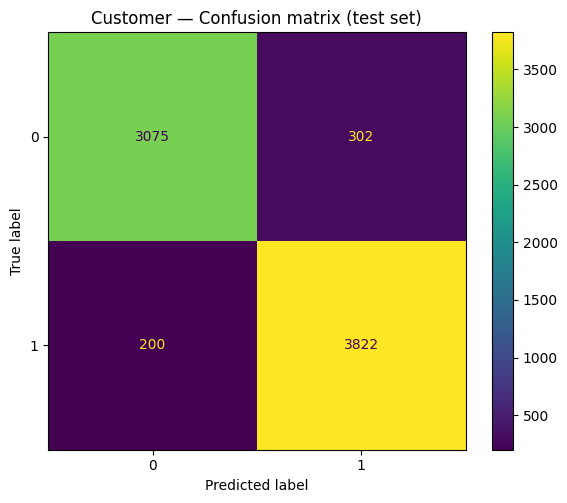

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
plt.title("Customer — Confusion matrix (test set)")
plt.tight_layout()
plt.show()

In [52]:
print("RandomForest")
print(classification_report(y_test, y_pred_rf))
print("GradientBoosting")
print(classification_report(y_test, y_pred_gb))

RandomForest
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      3377
           1       0.92      0.94      0.93      4022

    accuracy                           0.93      7399
   macro avg       0.93      0.93      0.93      7399
weighted avg       0.93      0.93      0.93      7399

GradientBoosting
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      3377
           1       0.93      0.95      0.94      4022

    accuracy                           0.93      7399
   macro avg       0.93      0.93      0.93      7399
weighted avg       0.93      0.93      0.93      7399



### We used Random Forest and HistGradientBoosting to validate that our other behavioral data—like tenure and login frequency—still hold meaningful patterns. This ensures our retention strategy is comprehensive rather than just reacting to point balances. GradientBoosting hyper focuses on top 3 or 4 features but we want to take a more broader view of more features. Churning is obviously more complicated and variable than that.

## 5. Churn probabilities → high-risk customers (Customer Churn)

In [ ]:
all_prob = modelHist.predict_proba(df[X_train.columns])[:, 1]
risk_df = df.copy() 
risk_df["churn_probability"] = all_prob

point_median = risk_df['points_in_wallet'].median()
risk_df['segment'] = np.where(
    (risk_df['churn_probability'] > 0.7) & (risk_df['points_in_wallet'] > point_median), 
    'VIP-At-Risk', 
    np.where(risk_df['churn_probability'] > 0.7, 'Standard-At-Risk', 'Stable')
)

risk_df = risk_df.sort_values("churn_probability", ascending=False).reset_index(drop=True)

# Save the high-risk customers with their assigned segments
high_risk_path = OUT_DIR / "customer_high_risk_segments.csv"
risk_df[["churn_probability", "segment", "points_in_wallet", "membership_category"]].to_csv(high_risk_path, index=False)

print(f"Saved {len(risk_df)} rows to {high_risk_path}")
display(risk_df[["churn_probability", "segment"]].head(10))

Saved 36992 rows to ..\outputs\customer_high_risk_segments.csv


,churn_probability,segment
0,0.990239,VIP-At-Risk
1,0.989415,Standard-At-Risk
2,0.988971,Standard-At-Risk
3,0.988696,Standard-At-Risk
4,0.988523,Standard-At-Risk
5,0.988389,VIP-At-Risk
6,0.988195,Standard-At-Risk
7,0.988184,VIP-At-Risk
8,0.988147,Standard-At-Risk
9,0.988128,Standard-At-Risk


## Comparing HistGradientBoosting vs RandomForest
* HistGradientBoosting has better recall so we use it for marking the customer segments. 
* high correlation indicates that both models agree for the most part 

In [55]:
risk_df["prob_Histo"] = modelHist.predict_proba(df[X_train.columns])[:, 1]
risk_df["prob_RF"] = rf_model.predict_proba(df[X_train.columns])[:, 1]

# Compare how many people each model puts in the 'High Risk' (> 0.7) bucket
histo_high_risk = (risk_df["prob_Histo"] > 0.7).sum()
rf_high_risk = (risk_df["prob_RF"] > 0.7).sum()

print(f"Histo identifies {histo_high_risk} high-risk customers.")
print(f"RF identifies {rf_high_risk} high-risk customers.")

# Check the correlation - if this is low (e.g. < 0.8), the models see different 'types' of churners
correlation = risk_df[["prob_Histo", "prob_RF"]].corr().iloc[0,1]
print(f"Correlation between model scores: {correlation:.3f}")

Histo identifies 18795 high-risk customers.
RF identifies 19682 high-risk customers.
Correlation between model scores: 0.965


### We have two options that we can consider:
* Use Histo if we care about more about accuracy: it has 0.95 recall and probably has fine-tuned its ability to catch almost every churner.
* Use RF if we care more about strategy: it identifies about 887 more customers (19,682 vs 18,795). "more safe than sorry"  mindset since it gives a wider range of potential churners.

In [ ]:
def create_actionable_segments(df, model):
    '''
    Segments customers based on predicted risk and business value.
    '''
    # Get the probability of churn (class 1)
    X_all = df.drop(columns=['churn_risk_score'], errors='ignore')
    df['risk_probability'] = model.predict_proba(X_all)[:, 1]
    
    # Define Segments based on High/Low Risk and High/Low Points (Value)
    point_median = df['points_in_wallet'].median()
    
    conditions = [
        (df['risk_probability'] > 0.7) & (df['points_in_wallet'] > point_median),
        (df['risk_probability'] > 0.7) & (df['points_in_wallet'] <= point_median),
        (df['risk_probability'] <= 0.7) & (df['points_in_wallet'] > point_median),
        (df['risk_probability'] <= 0.7) & (df['points_in_wallet'] <= point_median)
    ]
    
    choices = [
        'High Value - At Risk (VIP Recovery)',      # Best customers who are likely to leave soon
        'Low Value - At Risk (Standard Retarget)',  # Occasional customers who are likely to leave
        'High Value - Stable (Loyalty Rewards)',    # Best customers who are happy and staying
        'Low Value - Stable (Upsell Opportunity)'   # Occasional customers who are happy and staying
    ]
    
    df['segment'] = np.select(conditions, choices, default='Unclassified')
    return df

# Apply segments using rf
customer_segmented = create_actionable_segments(df.drop(columns=['security_no']), rf_model)

print(customer_segmented['segment'].value_counts())

segment
Low Value - At Risk (Standard Retarget)    16793
High Value - Stable (Loyalty Rewards)      13885
Low Value - Stable (Upsell Opportunity)     3425
High Value - At Risk (VIP Recovery)         2889
Name: count, dtype: int64


# Breaking down the segment results
| Segment | Count | Breakdown |
|:---|:---|:---|
Standard Retarget | 16,793 | Normal customers who just shop and go as they please. We can send automated emails/coupons or something.
Loyalty Rewards | 13,885 | They are the main customers. We should probably try to keep them happy with extra benefits. 
Upsell Opportunity | 3,425 | Happy customers but low spenders. We should probably try to make them like us more or get higher memberships.
VIP Recovery | 2,889 | Danger zone group. They are important, and it looks like they are going to churn. We should try to pull them back in for sure.

In [ ]:
high_risk = risk_df[risk_df['churn_probability'] > 0.8]
high_risk.to_csv(f"{OUT_DIR}/high_risk_customers.csv", index=False)

profiles = risk_df.groupby('segment').size().to_dict()
with open(f"{OUT_DIR}/segment_profiles.json", "w") as f:
    json.dump(profiles, f, indent=2)

campaigns = risk_df[['security_no', 'segment']].copy()
campaigns['action'] = np.where(campaigns['segment'] == 'VIP Recovery', 'Direct Phone Call', 'Email Discount')
campaigns.to_csv(f"{OUT_DIR}/campaigns.csv", index=False)

## 6. Global Churn Drivers (Feature Importance)

### Random Forest builds many independent trees that look at different "subsets" of features. This gives us a wider lens on churn drivers—capturing signals from tenure and engagement that a more aggressive model might ignore.
* we acknowledge that churning is complex and should be considered as such, so we do not choose the hyper focusing GradientBoosting.
* also very stable and more comprehensive than HistGradientBoosting

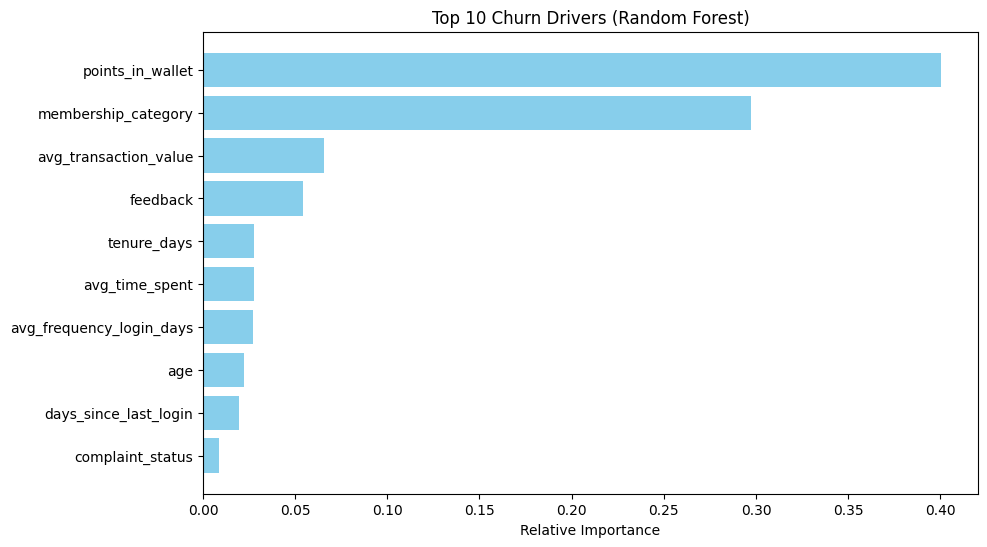

In [48]:
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Churn Drivers (Random Forest)")
plt.xlabel("Relative Importance")
plt.show()

* Customer’s current loyalty point balance is the strongest signal of whether they will stay or leave.
* Financial connection to the business is a strong and obvious sign of potential churners. 
* Other features may not be as relevant in this dataset, but are still useful to our models 

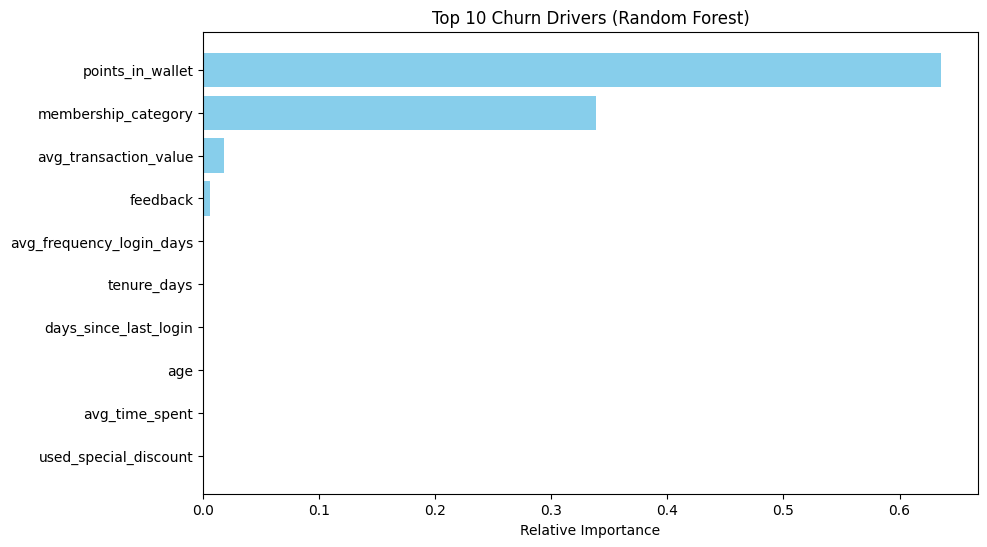

In [54]:
importances = gb_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Churn Drivers (Random Forest)")
plt.xlabel("Relative Importance")
plt.show()

## 7. Behavioral Drivers (Feedback)

In [51]:
# Analyzing churn rate by feedback category
feedback_analysis = df.groupby('feedback')['churn_risk_score'].mean().sort_values(ascending=False)
feedback_map = {
    0: 'Poor Product Quality',
    1: 'Too many Ads',
    2: 'Poor Customer Service',
    3: 'Poor Website',
    4: 'No reason specified',
    5: 'Good Product Quality',
    6: 'Reasonable Price',
    7: 'User Friendly Portal',
    8: 'Products always in Stock'
}

feedback_summary = df.groupby('feedback')['churn_risk_score'].mean().reset_index()
feedback_summary['feedback_text'] = feedback_summary['feedback'].map(feedback_map)

# Sort by Churn Rate to show the most dangerous feedback first
feedback_summary = feedback_summary.sort_values('churn_risk_score', ascending=False)

display(feedback_summary[['feedback_text', 'churn_risk_score']])

,feedback_text,churn_risk_score
2,Poor Customer Service,0.649921
1,Too many Ads,0.638516
0,Poor Product Quality,0.634976
3,Poor Website,0.631797
7,User Friendly Portal,0.627011
4,No reason specified,0.000000
5,Good Product Quality,0.000000
6,Reasonable Price,0.000000
8,Products always in Stock,0.000000


* Poor reviews and experiences are also a clear sign of customer churners. This is something we already know to be a strong sign, and it is good that our model can see that, and match our natural intuition.